In [32]:
print("all okay")

all okay


In [33]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model_name="deepseek-r1-distill-llama-70b",
    temperature=0
)
response=llm.invoke("what is length of wall of china?")

In [34]:
response

AIMessage(content="<think>\nOkay, so I need to figure out the length of the Great Wall of China. I remember hearing that it's really long, but I'm not exactly sure how long. I think it's somewhere in the thousands of miles, but I'm not certain. Let me try to break this down.\n\nFirst, I know the Great Wall is a series of fortifications built across several Chinese dynasties. It wasn't built all at once, so maybe that's why the length can vary. I've heard different numbers before, like 13,000 miles or 21,000 kilometers. But I'm not sure which one is accurate.\n\nI should consider the sources of this information. Maybe some people measure it differently. For example, if you include all the branches and sections, it might add up to a longer distance. But if you just take the main wall, it might be shorter. I think the Chinese government did a survey a while back, so that might be a reliable source.\n\nWait, I think they used advanced technology like GPS and satellites to measure it more a

In [35]:
response.content

"<think>\nOkay, so I need to figure out the length of the Great Wall of China. I remember hearing that it's really long, but I'm not exactly sure how long. I think it's somewhere in the thousands of miles, but I'm not certain. Let me try to break this down.\n\nFirst, I know the Great Wall is a series of fortifications built across several Chinese dynasties. It wasn't built all at once, so maybe that's why the length can vary. I've heard different numbers before, like 13,000 miles or 21,000 kilometers. But I'm not sure which one is accurate.\n\nI should consider the sources of this information. Maybe some people measure it differently. For example, if you include all the branches and sections, it might add up to a longer distance. But if you just take the main wall, it might be shorter. I think the Chinese government did a survey a while back, so that might be a reliable source.\n\nWait, I think they used advanced technology like GPS and satellites to measure it more accurately. That wo

This is my Custom Tools

In [36]:
from langchain.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """
    Multiply two integers.

    Args:
        a (int): The first integer.
        b (int): The second integer.

    Returns:
        int: The product of a and b.
    """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """
    Add two integers.

    Args:
        a (int): The first integer.
        b (int): The second integer.

    Returns:
        int: The sum of a and b.
    """
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """
    Divide two integers.

    Args:
        a (int): The numerator.
        b (int): The denominator (must not be 0).

    Returns:
        float: The result of division.
    """
    if b == 0:
        raise ValueError("Denominator cannot be zero.")
    return a / b

Importing the inbuilt tool

In [37]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [38]:
search.invoke("what is the latest update on iphone17 release?")

"Planned for September 2025, the iPhone 17 models could feature larger display sizes, ProMotion across the lineup, Wi-Fi 7, and more. We're still in the middle of the iPhone 16 release cycle, but ... This beta release will be available to anyone who wants it via enrollment at beta.apple.com. Like all beta software, iOS 26's public beta is expected to include bugs and performance issues that ... New iPhone 17 colors. Rumors of a new color for the iPhone started in April, when Twitter user and leaker Majin Bu (not the Dragon Ball Z character) posted that the iPhone 17 Pro and Pro Max could ... The iPhone 17 is already shaping up to be one of its biggest updates in years. From the ultra-slim iPhone 17 Air to a new matte finish, upgraded front cameras, a possible sky blue model and more ... • The iPhone 17's display may not match what the Pro model offers. • iOS 26, Apple's iPhone software update for later this year, got a preview at WWDC. • The iPhone 17 could support a new ..."

In [39]:
tools=[multiply, add, divide, search]

In [40]:
llm_with_tools=llm.bind_tools(tools)

In [41]:
response=llm_with_tools.invoke("how are you?")


In [42]:
response.content

"I'm just a program, so I don't have feelings, but thanks for asking! How can I assist you today?"

In [43]:
response.tool_calls

[]

In [44]:
response=llm_with_tools.invoke("what is 2+2?")

In [45]:
response.content

''

In [46]:
response.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'grwm7d1rd',
  'type': 'tool_call'}]

In [47]:
response=llm_with_tools.invoke("what is 10/2?")

In [48]:
response.content


''

In [49]:
response.tool_calls

[{'name': 'divide',
  'args': {'a': 10, 'b': 2},
  'id': 'ceke6n5md',
  'type': 'tool_call'}]

In [50]:
response=llm_with_tools.invoke("what is a current age of the TATA Group?")

In [51]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'w4njmcadq', 'function': {'arguments': '{"query":"TATA Group founding year"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 417, 'prompt_tokens': 402, 'total_tokens': 819, 'completion_time': 1.714568507, 'prompt_time': 0.025886684, 'queue_time': 0.227498547, 'total_time': 1.7404551910000001}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--a1c9cb2b-bc0e-47cf-b8c9-8f272d09bb46-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'TATA Group founding year'}, 'id': 'w4njmcadq', 'type': 'tool_call'}], usage_metadata={'input_tokens': 402, 'output_tokens': 417, 'total_tokens': 819})

In [52]:
response.content

''

In [53]:
response.tool_calls

[{'name': 'duckduckgo_search',
  'args': {'query': 'TATA Group founding year'},
  'id': 'w4njmcadq',
  'type': 'tool_call'}]

In [62]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState, StateGraph, END, START


In [54]:
SYSTEM_PROMPT="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs."


In [55]:
user_query=["tell me what is 2+2"]

In [56]:
[SYSTEM_PROMPT]+user_query

['You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.',
 'tell me what is 2+2']

In [63]:
def function_1(state:MessagesState):
    
    user_question=state["messages"]
    
    input_question = [SYSTEM_PROMPT]+user_question
    
    response = llm_with_tools.invoke(input_question)
    
    return {
        "messages":[response]
    }
    
    

In [65]:
builder=StateGraph(MessagesState)

In [66]:
builder.add_node("llm_decision_step",function_1)

In [67]:
tools

[StructuredTool(name='multiply', description='Multiply two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The product of a and b.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000002DBCBA3F9C0>),
 StructuredTool(name='add', description='Add two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The sum of a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x000002DBCA9125C0>),
 StructuredTool(name='divide', description='Divide two integers.\n\nArgs:\n    a (int): The numerator.\n    b (int): The denominator (must not be 0).\n\nReturns:\n    float: The result of division.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x000002DBCBA3D4E0>),
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', 

In [68]:
from langgraph.prebuilt import ToolNode
builder.add_node("tools",ToolNode(tools))

In [69]:
builder.add_edge(START,"llm_decision_step")

In [70]:
from langgraph.prebuilt import tools_condition
builder.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)

In [71]:
builder.add_edge("tools","llm_decision_step")

In [72]:
react_graph=builder.compile()

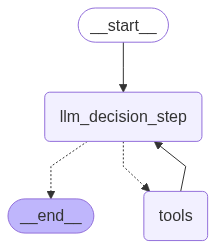

In [73]:
from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [74]:
message=[HumanMessage(content="What is 2 times of narendramodi's age?")]

In [75]:
react_graph.invoke({"messages":message})

{'messages': [HumanMessage(content="What is 2 times of narendramodi's age?", additional_kwargs={}, response_metadata={}, id='83bbfe9f-589d-4436-b5ed-adacc4ff5170'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'p6xyskwy9', 'function': {'arguments': '{"query":"Narendra Modi age"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 308, 'prompt_tokens': 423, 'total_tokens': 731, 'completion_time': 1.12, 'prompt_time': 0.034582758, 'queue_time': 0.206096996, 'total_time': 1.154582758}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--5fbaa520-0928-4c44-a0e8-f1031936e36d-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Narendra Modi age'}, 'id': 'p6xyskwy9', 'type': 'tool_call'}], usage_metadata={'input_tokens': 423, 'output_tokens': 308, 'total_tokens': 731}),
  ToolMessage(content='Narendra Modi is t

In [76]:
message = [HumanMessage(content="How much is the net worth of Elon Musk, and divide it by 2?")]

In [77]:
react_graph.invoke({"messages":message})

{'messages': [HumanMessage(content='How much is the net worth of Elon Musk, and divide it by 2?', additional_kwargs={}, response_metadata={}, id='83125acd-dc4f-4b37-a439-fe69e0b5d155'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'xcb94cdrn', 'function': {'arguments': '{"query":"Elon Musk net worth 2023"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 602, 'prompt_tokens': 427, 'total_tokens': 1029, 'completion_time': 2.212423192, 'prompt_time': 0.034142366, 'queue_time': 0.20525261, 'total_time': 2.246565558}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--a7a5f301-d38a-4617-b191-0b50237c613f-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Elon Musk net worth 2023'}, 'id': 'xcb94cdrn', 'type': 'tool_call'}], usage_metadata={'input_tokens': 427, 'output_tokens': 602, 'total_tokens': 1029})

In [78]:
message = [HumanMessage(content="What is the speed of light in m/s and multiply it by 10?")]

In [79]:
response=react_graph.invoke({"messages":message})

In [80]:
response["messages"][-1].content

'The speed of light is approximately 299,792,000 meters per second. When multiplied by 10, the result is 2,997,920,000 meters per second.\n\n**Step-by-Step Explanation:**\n\n1. **Identify the Speed of Light:**\n   - The speed of light in a vacuum is a well-known physical constant.\n   - It is approximately 299,792 kilometers per second.\n\n2. **Convert Kilometers to Meters:**\n   - Since 1 kilometer equals 1,000 meters, multiply the speed by 1,000 to convert it to meters per second.\n   - Calculation: 299,792 km/s * 1,000 = 299,792,000 m/s.\n\n3. **Multiply by 10:**\n   - To find ten times the speed of light in meters per second, multiply the converted speed by 10.\n   - Calculation: 299,792,000 m/s * 10 = 2,997,920,000 m/s.\n\n**Final Answer:**\nThe speed of light is 299,792,000 meters per second, and when multiplied by 10, it equals 2,997,920,000 meters per second.'

In [81]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the speed of light in m/s and multiply it by 10?
================================== Ai Message ==================================
Tool Calls:
  multiply (7dnx9fhem)
 Call ID: 7dnx9fhem
  Args:
    a: 299792000
    b: 10
================================= Tool Message =================================
Name: multiply

2997920000
================================== Ai Message ==================================
Tool Calls:
  multiply (1w77gfyjf)
 Call ID: 1w77gfyjf
  Args:
    a: 299792000
    b: 10
================================= Tool Message =================================
Name: multiply

2997920000
================================== Ai Message ==================================

The speed of light is approximately 299,792,000 meters per second. When multiplied by 10, the result is 2,997,920,000 meters per second.

**Step-by-Step Explanation:**

1. **Identify the Speed of Light:**
   - The speed o

In [83]:
import yfinance as yf

In [84]:
@tool
def get_stock_price(ticker:str)->str:
    """
    Fetches the previous closing price of a given stock ticker from Yahoo Finance.

    Args:
        ticker (str): The stock ticker symbol (e.g., 'AAPL', 'TSLA', 'NIFTY.BO').

    Returns:
        str: A message with the stock's previous closing price.
    """
    try:
        stock = yf.Ticker(ticker)
        price = stock.info.get('previousClose')
        if price is None:
            return f"Could not fetch price for ticker '{ticker}'."
        return f"The last closing price of {ticker.upper()} was ${price:.2f}."
    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"
     
    

In [85]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $195.64.'

In [86]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $316.28.'

In [87]:
tools

[StructuredTool(name='multiply', description='Multiply two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The product of a and b.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000002DBCBA3F9C0>),
 StructuredTool(name='add', description='Add two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The sum of a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x000002DBCA9125C0>),
 StructuredTool(name='divide', description='Divide two integers.\n\nArgs:\n    a (int): The numerator.\n    b (int): The denominator (must not be 0).\n\nReturns:\n    float: The result of division.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x000002DBCBA3D4E0>),
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', 

In [88]:
tools = [add, multiply, divide, search,get_stock_price]

In [89]:
llm_with_tools=llm.bind_tools(tools)

In [90]:
response=llm_with_tools.invoke("can you give me a latest stock price of adani greens?")

In [91]:
response.content

''

In [92]:
response.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'ADANIGREEN.NS'},
  'id': '5wywvgbp6',
  'type': 'tool_call'}]

In [93]:
SYSTEM_PROMPT = SystemMessage(
    content="You are a helpful assistant tasked with using search, the yahoo finance tool and performing arithmetic on a set of inputs."
)
def function_1(state:MessagesState):
    
    user_question=state["messages"]
    
    input_question = [SYSTEM_PROMPT]+user_question
    
    response = llm_with_tools.invoke(input_question)
    
    return {
        "messages":[response]
    }

In [94]:
workflow = StateGraph(MessagesState)
workflow.add_node("llm_decision_step", function_1)
workflow.add_node("tools", ToolNode(tools))
workflow.add_edge(START, "llm_decision_step")
workflow.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)
workflow.add_edge("tools", "llm_decision_step")
react_graph2 = workflow.compile()

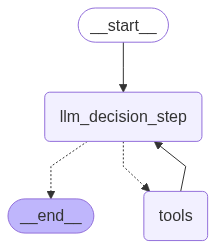

In [95]:
display(Image(react_graph2.get_graph(xray=True).draw_mermaid_png()))

In [96]:
messages = [HumanMessage(content="add 1000 in the current stock price of Apple.")]
messages = react_graph2.invoke({"messages": messages})

In [97]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

add 1000 in the current stock price of Apple.
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (b41rhkfx0)
 Call ID: b41rhkfx0
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

The last closing price of AAPL was $195.64.
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (x6q4edfvz)
 Call ID: x6q4edfvz
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

The last closing price of AAPL was $195.64.
================================== Ai Message ==================================

The result of adding 1000 to the current stock price of Apple is **$1195.64**.


In [99]:
messages = [HumanMessage(content="can you give me 2 times of current stock price of Apple with the latest news of the Apple.")]
messages = react_graph2.invoke({"messages": messages})

KeyboardInterrupt: 